In [266]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
from PIL import Image
import cv2 
import matplotlib.pyplot as plt

In [267]:
image = cv2.imread('./data/train/train_000579.png')

In [268]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

# Custom Resize with Anti-Aliasing
class ResizeWithAntiAliasing(A.ImageOnlyTransform):
    def __init__(self, width, height, always_apply=False, p=1.0):
        super(ResizeWithAntiAliasing, self).__init__(always_apply, p)
        self.width = width
        self.height = height

    def apply(self, image, **params):
        # Convert the image to a PIL image, apply resizing with anti-aliasing
        image_pil = Image.fromarray(image)
        image_resized = image_pil.resize((self.width, self.height), Image.Resampling.LANCZOS)
        return np.array(image_resized)

In [269]:
# Define transformations for validation (no augmentation)
val_transform = A.Compose([
    ResizeWithAntiAliasing(width=224, height=224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    A.ToGray(p=1.0),  # Convert to grayscale
    ToTensorV2(),
])

(np.float64(-0.5), np.float64(3459.5), np.float64(1899.5), np.float64(-0.5))

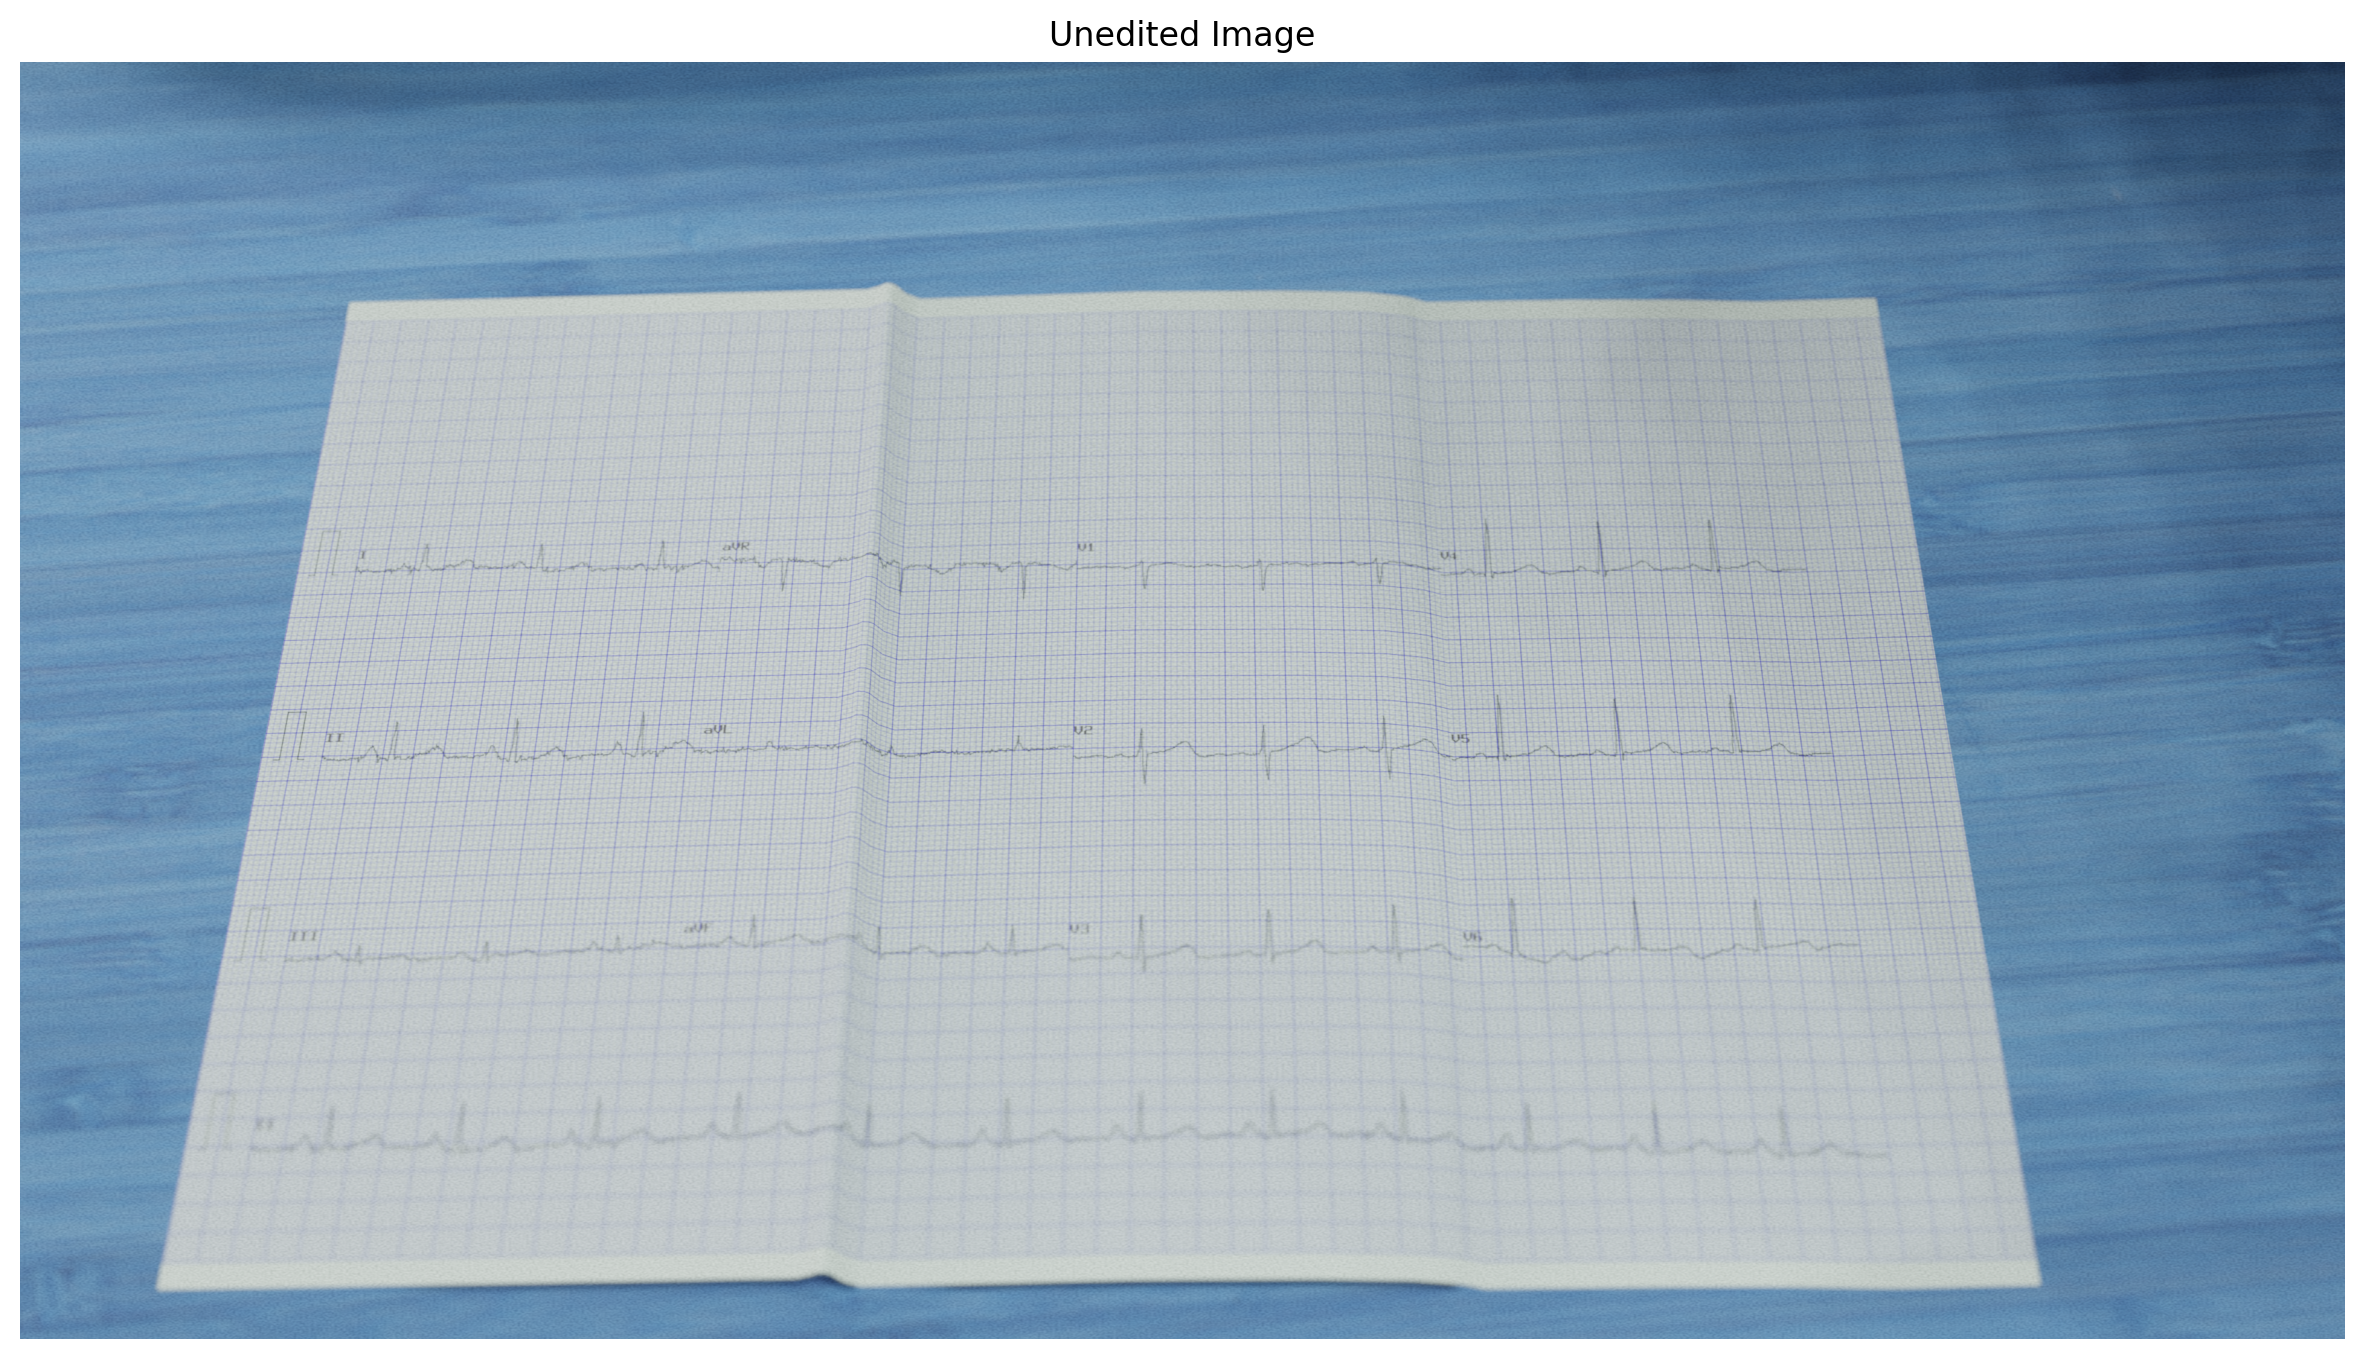

In [270]:
plt.figure(figsize=(15, 15), dpi=200)  # Increase the figure size and DPI
plt.imshow(image)
plt.title('Unedited Image')
plt.axis('off')

In [271]:
# apply transformations to image 
image_transform = val_transform(image=image)
transformed_image = image_transform['image']
transformed_image = transformed_image.mean(dim=0, keepdim=True)  # Convert 3 channels to 1 channel

Text(0.5, 1.0, 'Image after Transformation')

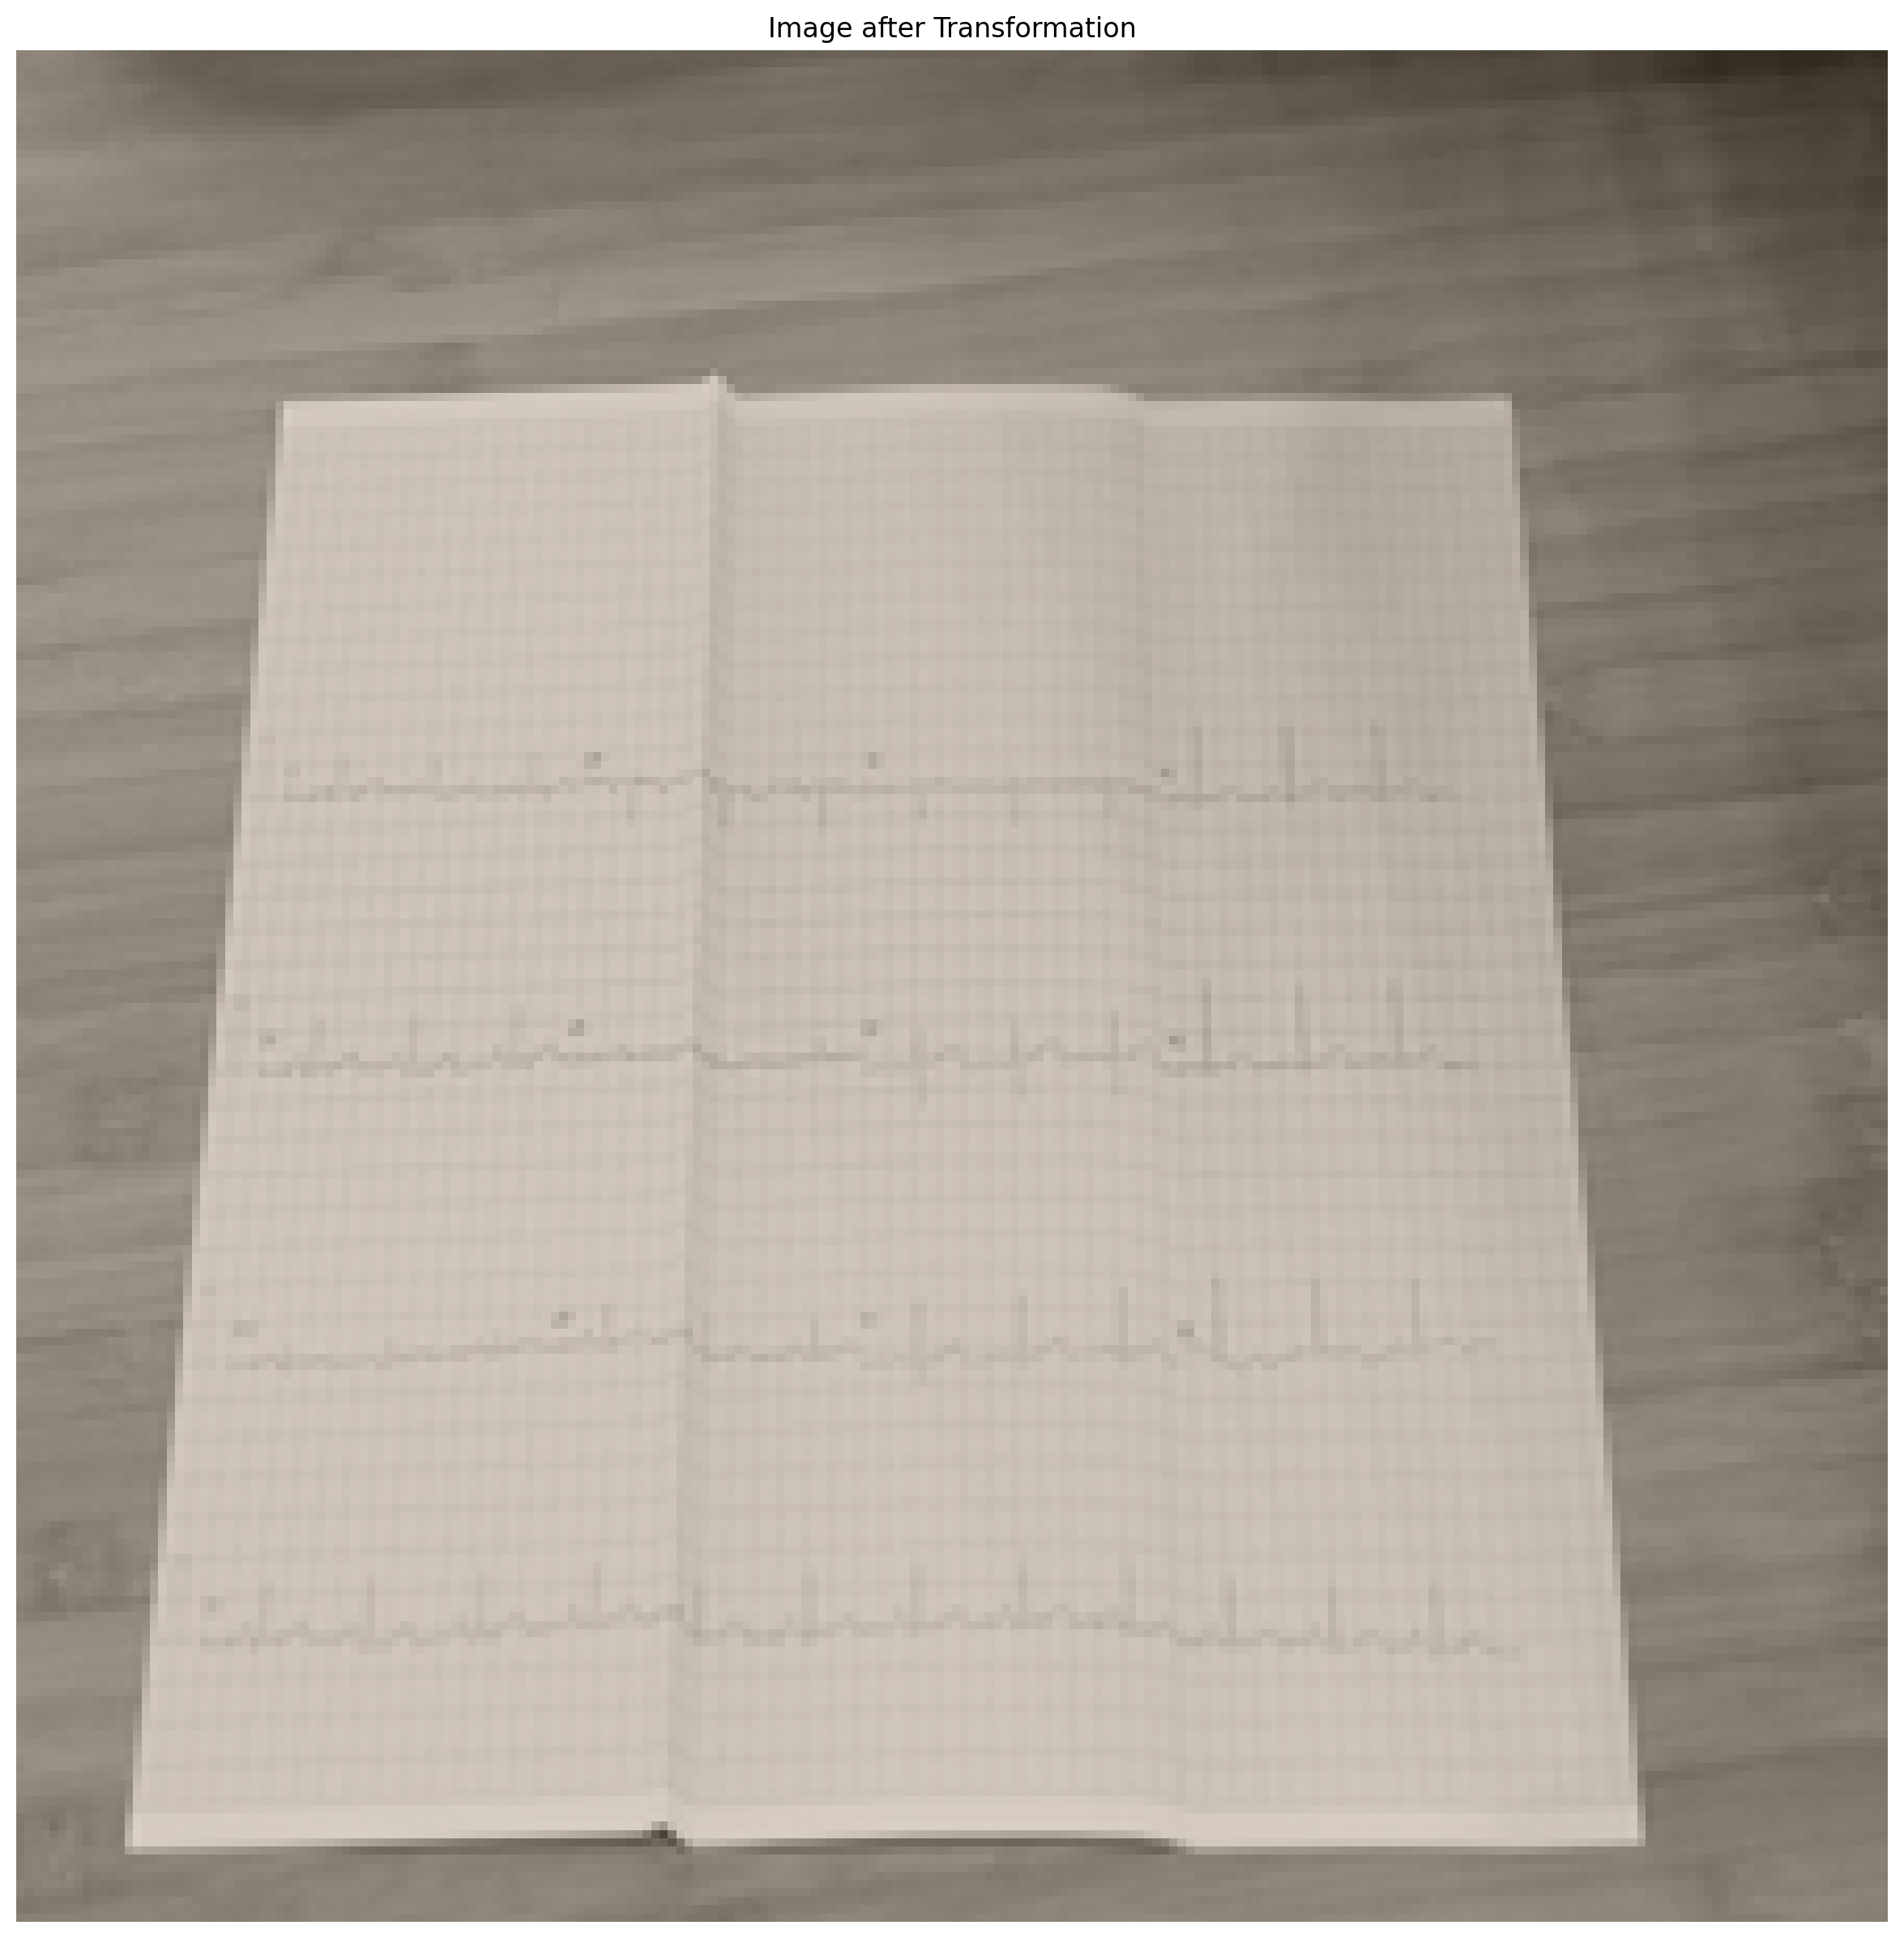

In [272]:
# need to convert back to numpy array to visualise it
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image_np = transformed_image.permute(1, 2, 0).numpy()  # Convert to HWC
image_np = (image_np * std + mean)  # Denormalize
image_np = np.clip(image_np, 0, 1)  # Clip values to valid range [0, 1]
# If grayscale, repeat the channel to make it 3-channel for visualization
if image_np.shape[-1] == 1:
    image_np = np.repeat(image_np, 3, axis=-1) 

plt.figure(figsize=(15, 15), dpi=200)  # Increase the figure size and DPI
plt.imshow(image_np)
plt.axis('off')
plt.title('Image after Transformation')